In [1]:
!pip install lime

^C


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.9 MB 2.1 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/12.9 MB 2.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.8/12.9 MB 2.5 MB/s eta 0:00:05
   -------- ------------------------------- 2.6/12.9 MB 2.7 MB/s eta 0:00:04
   ---------- ----------------------------- 3.4/12.9 MB 2.9 MB/s eta 0:00:04
   ------------ --------------------------- 3.9/12.9 MB 2.9 MB/s eta 0:00:04
   -------------- ------------------------- 4.7/12.9 MB 3.0 MB/s eta 0:00:03
   ---------------- ----------------------- 5.2/12.9 MB 2.9 MB/s eta 0:00:03
   ------------------ --------------------- 6.0/12.9 MB 3.0 MB/s eta 0:00:03
   -------------------- ------------------- 6.6/12.9 MB 2.9 MB/s 

IMPORT

In [4]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

#nltk.download("stopwords")
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words("english"))
lemmatizer= WordNetLemmatizer()

# Modelling
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

#Lime
from lime import lime_text
from lime.lime_text import LimeTextExplainer
from lime.lime_text import IndexedString,IndexedCharacters
from lime.lime_base import LimeBase
from lime.lime_text import explanation
sns.set(font_scale=1.3)
nltk.download('omw-1.4')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

LOAD DATASET

In [5]:
# Read datasets
df_train = pd.read_csv('train.csv')
df_val = pd.read_csv('val.csv')
df_test = pd.read_csv('test.csv')

In [6]:
df_train.head()

,Text,Emotion
0,"I sould have assissted in the stabbing, even c...",surprise
1,Apologies for vertical view! Bonus commentary ...,fear
2,The thought of shooting anything at asylum see...,fear
3,I thought he was trolling oops,fear
4,"Damn you really need a girlfriend, dude. 🤣",fear


In [7]:
print(df_train.shape)

(6499, 2)


In [8]:
df_test.head()

,Text,Emotion
0,"Out of curiosity, what's wrong with the tribal...",happiness
1,I did.,happiness
2,Holy shit that’s nothing,sadness
3,"Maybe one ""episode"", but they're definitely go...",happiness
4,GAA' isn't a sport...,anger


In [9]:
print(df_test.shape)

(813, 2)


In [10]:
df_val.head()

,Text,Emotion
0,Sadly it happens randomly and I wouldn't want ...,sadness
1,Please don’t! Don’t stop fighting! I made it t...,surprise
2,[NAME] is there anything more depressing than ...,sadness
3,its not the best but i think its better than t...,happiness
4,Understood - PM was all gears and no downtime....,anger


In [11]:
print(df_val.shape)

(812, 2)


TRAIN DATA ANALYSIS

In [12]:
df_train.Emotion.value_counts()

Emotion
anger        1084
surprise     1083
fear         1083
happiness    1083
neutral      1083
sadness      1083
Name: count, dtype: int64

In [13]:
df_train.Emotion.value_counts() / df_train.shape[0] *100

Emotion
anger        16.679489
surprise     16.664102
fear         16.664102
happiness    16.664102
neutral      16.664102
sadness      16.664102
Name: count, dtype: float64

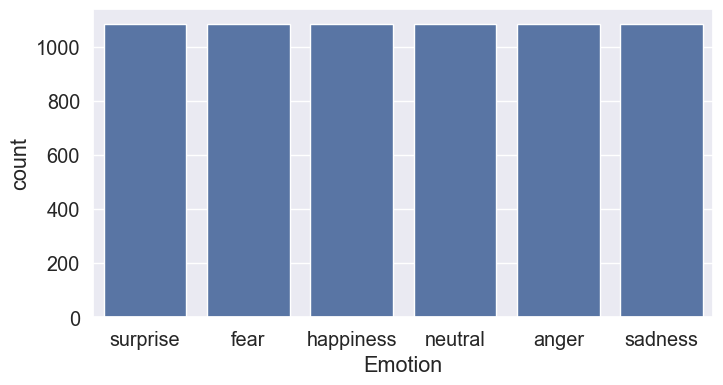

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_train);

In [15]:
df_train.isnull().sum()

Text       0
Emotion    0
dtype: int64

In [16]:
df_train.duplicated().sum()

np.int64(0)

In [17]:
#removing duplicated values
index = df_train[df_train.duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [18]:
#print the rows which are duplicated (duplicated in the text but with different emotions)
df_train[df_train['Text'].duplicated() == True]

,Text,Emotion


In [19]:
#removing duplicated text
index = df_train[df_train['Text'].duplicated() == True].index
df_train.drop(index, axis = 0, inplace = True)
df_train.reset_index(inplace=True, drop = True)

In [21]:
#Count the number of stopwords in the data
temp =df_train.copy()
stop_words = set(stopwords.words("english"))
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()

stop_words
5     758
4     754
3     742
2     718
6     681
1     663
7     557
8     466
0     466
9     296
10    189
11    130
12     43
13     23
14     10
15      3
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

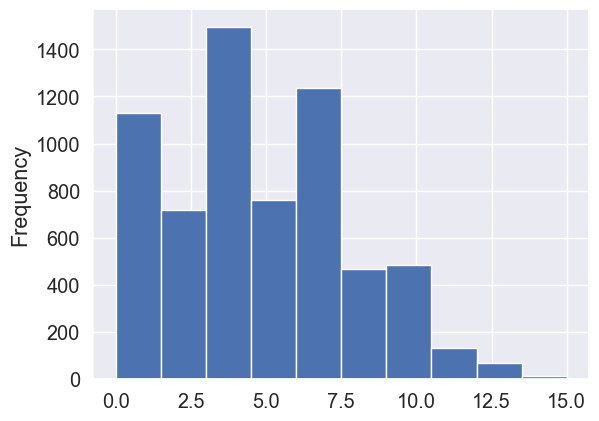

In [22]:
#distribution of stopwords visually
temp['stop_words'].plot(kind= 'hist')

TEST DATA ANALYSIS

In [23]:
#check if the data is balanced or not
df_test.Emotion.value_counts()

Emotion
sadness      136
fear         136
neutral      136
happiness    135
anger        135
surprise     135
Name: count, dtype: int64

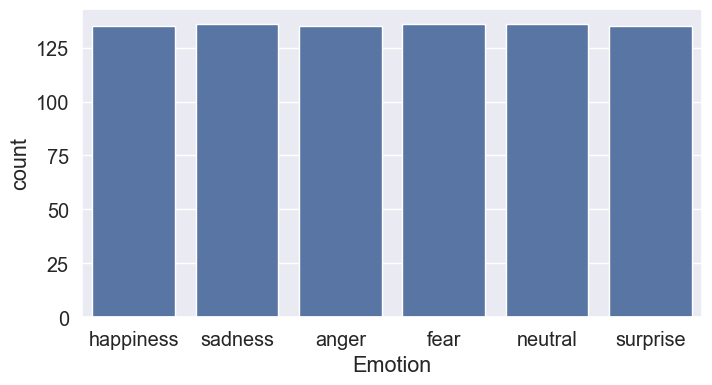

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_test);

In [25]:
#print the number of null values in each column
df_test.isnull().sum()

Text       0
Emotion    0
dtype: int64

In [26]:
#print the number of duplicated values
df_test.duplicated().sum()

np.int64(0)

In [27]:
#print the rows which are duplicated
df_test[df_test['Text'].duplicated() == True]

,Text,Emotion


In [28]:
#Count the number of stopwords in the data
temp =df_test.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()

stop_words
4     101
3      98
2      95
5      95
1      82
6      76
7      70
0      60
8      51
9      44
10     22
11     12
12      5
13      2
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

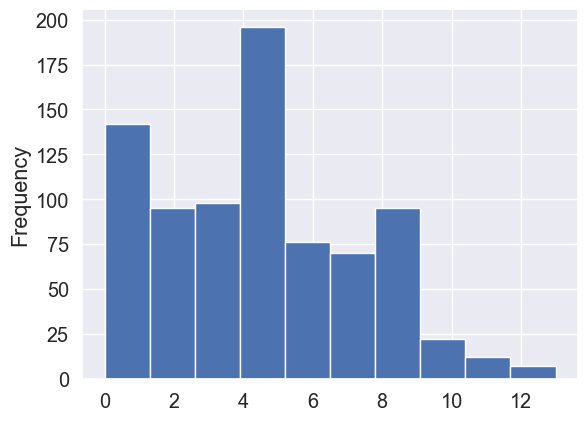

In [29]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist')

VAL DATA ANALYSIS

In [30]:
#check if the data is balanced or not
df_val.Emotion.value_counts()

Emotion
surprise     136
happiness    136
sadness      135
anger        135
neutral      135
fear         135
Name: count, dtype: int64

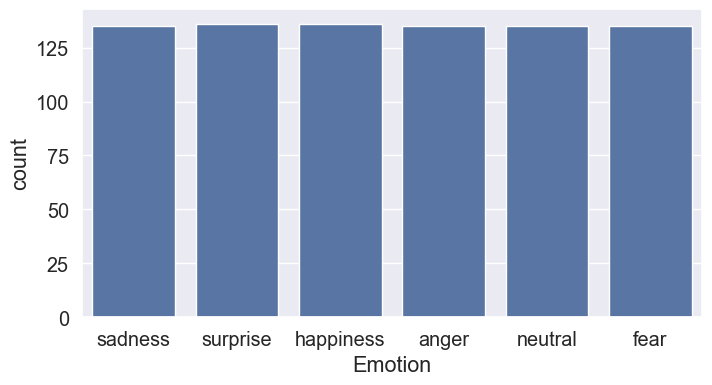

In [31]:
plt.figure(figsize=(8,4))
sns.countplot(x='Emotion', data=df_val);

In [32]:
#print the number of null values in each column
df_val.isnull().sum()

Text       0
Emotion    0
dtype: int64

In [33]:
#print the number of duplicated values
df_val.duplicated().sum()

np.int64(0)

In [34]:
#print the rows which are duplicated
df_val[df_val['Text'].duplicated() == True]

,Text,Emotion


In [35]:
#removing duplicated text
index = df_val[df_val['Text'].duplicated() == True].index
df_val.drop(index, axis = 0, inplace = True)
df_val.reset_index(inplace=True, drop = True)

In [36]:
#Count the number of stopwords in the data
temp =df_val.copy()
temp['stop_words'] = temp['Text'].apply(lambda x: len(set(x.split()) & set(stop_words)))
temp.stop_words.value_counts()[:10]

stop_words
3    103
5     94
1     90
2     88
4     86
6     80
7     72
8     56
0     55
9     39
Name: count, dtype: int64

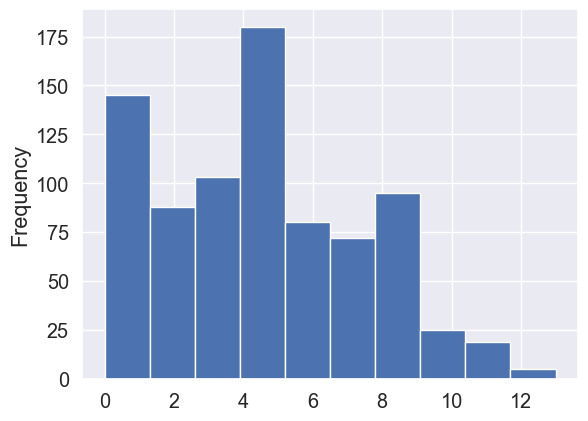

In [37]:
sns.set(font_scale=1.3)
temp['stop_words'].plot(kind= 'hist');

COMPARE

In [39]:
def dataframe_difference(df1, df2, which=None):
    """Find rows which are different between two DataFrames."""
    comparison_df = df1.merge(
        df2,
        indicator=True,
        how='outer'
    )

    if which is None:
        diff_df = comparison_df[comparison_df['_merge'] != 'both']
    else:
        diff_df = comparison_df[comparison_df['_merge'] == which]

    return diff_df

In [40]:
dataframe_difference(df_train, df_test, which='both')

,Text,Emotion,_merge


In [41]:
dataframe_difference(df_train, df_val, which='both')

,Text,Emotion,_merge


In [42]:
dataframe_difference(df_val, df_test, which='both')

,Text,Emotion,_merge


DATA CLEANING

In [44]:
def lemmatization(text):
    lemmatizer= WordNetLemmatizer()

    text = text.split()

    text=[lemmatizer.lemmatize(y) for y in text]

    return " " .join(text)

def remove_stop_words(text):

    Text=[i for i in str(text).split() if i not in stop_words]
    return " ".join(Text)

def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

def lower_case(text):

    text = text.split()

    text=[y.lower() for y in text]

    return " " .join(text)

def Removing_punctuations(text):
    ## Remove punctuations
    text = re.sub(r'[%s]' % re.escape(r"""!"#$%&'()*+,،-./:;<=>؟?@[\]^_`{|}~"""), ' ', text)
    text = text.replace('؛',"", )

    ## remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_small_sentences(df):
    for i in range(len(df)):
        if len(df.text.iloc[i].split()) < 3:
            df.text.iloc[i] = np.nan

def normalize_text(df):
    df.Text=df.Text.apply(lambda text : lower_case(text))
    df.Text=df.Text.apply(lambda text : remove_stop_words(text))
    df.Text=df.Text.apply(lambda text : Removing_numbers(text))
    df.Text=df.Text.apply(lambda text : Removing_punctuations(text))
    df.Text=df.Text.apply(lambda text : Removing_urls(text))
    df.Text=df.Text.apply(lambda text : lemmatization(text))
    return df

def normalized_sentence(sentence):
    sentence= lower_case(sentence)
    sentence= remove_stop_words(sentence)
    sentence= Removing_numbers(sentence)
    sentence= Removing_punctuations(sentence)
    sentence= Removing_urls(sentence)
    sentence= lemmatization(sentence)
    return sentence

In [45]:
df_train= normalize_text(df_train)
df_test= normalize_text(df_test)
df_val= normalize_text(df_val)

MODELING

In [46]:
#Preprocess text
X_train = df_train['Text'].values
y_train = df_train['Emotion'].values

X_test = df_test['Text'].values
y_test = df_test['Emotion'].values

X_val = df_val['Text'].values
y_val = df_val['Emotion'].values

In [47]:
def train_model(model, data, targets):

    # Create a Pipeline object with a TfidfVectorizer and the given model
    text_clf = Pipeline([('vect',TfidfVectorizer()),
                         ('clf', model)])
    # Fit the model on the data and targets
    text_clf.fit(data, targets)
    return text_clf

In [48]:
def get_F1(trained_model,X,y):

    # Make predictions on the input data using the trained model
    predicted=trained_model.predict(X)
    # Calculate the F1 score for the predictions
    f1=f1_score(y,predicted, average=None)
    # Return the F1 score
    return f1

Training the Random Forest model on the Training set

In [49]:
#Train the model with the training data
RF = train_model(RandomForestClassifier(random_state = 0), X_train, y_train)

#test the model with the test data
y_pred=RF.predict(X_test)

#calculate the accuracy
RF_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', RF_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(RF, X_test, y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.44157441574415746 



,F1 score
surprise,0.384906
fear,0.502203
happiness,0.564286
neutral,0.337079
anger,0.424490
sadness,0.474308


In [50]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.39      0.38      0.38       135
        fear       0.63      0.42      0.50       136
   happiness       0.54      0.59      0.56       135
     neutral       0.27      0.44      0.34       136
     sadness       0.48      0.38      0.42       136
    surprise       0.51      0.44      0.47       135

    accuracy                           0.44       813
   macro avg       0.47      0.44      0.45       813
weighted avg       0.47      0.44      0.45       813



In [52]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional

#nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
lemmatizer= WordNetLemmatizer()

# Modelling
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.svm import SVC

#Lime
from lime import lime_text
from lime.lime_text import LimeTextExplainer
from lime.lime_text import IndexedString,IndexedCharacters
from lime.lime_base import LimeBase
from lime.lime_text import explanation
sns.set(font_scale=1.3)
nltk.download('omw-1.4')

[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

logistic regression

In [53]:
#Train the model with the training data
log_reg = train_model(LogisticRegression(solver='liblinear',random_state = 0), X_train, y_train)
#Make a single prediction
y_pred=log_reg.predict(['Happy'])
y_pred
#test the model with the test data
y_pred=log_reg.predict(X_test)

#calculate the accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', log_reg_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(log_reg,X_test,y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.43419434194341944 



,F1 score
surprise,0.395522
fear,0.484127
happiness,0.607774
neutral,0.287671
anger,0.376000
sadness,0.455516


In [54]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.40      0.39      0.40       135
        fear       0.53      0.45      0.48       136
   happiness       0.58      0.64      0.61       135
     neutral       0.27      0.31      0.29       136
     sadness       0.41      0.35      0.38       136
    surprise       0.44      0.47      0.46       135

    accuracy                           0.43       813
   macro avg       0.44      0.43      0.43       813
weighted avg       0.44      0.43      0.43       813



svm

In [55]:
#Train the model with the training data
SVM = train_model(SVC(random_state = 0), X_train, y_train)

#test the model with the test data
y_pred=SVM.predict(X_test)

#calculate the accuracy
SVM_accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: ', SVM_accuracy,'\n')

#calculate the F1 score
f1_Score = get_F1(SVM,X_test,y_test)
pd.DataFrame(f1_Score, index=df_train.Emotion.unique(), columns=['F1 score'])

Accuracy:  0.4280442804428044 



,F1 score
surprise,0.383459
fear,0.469565
happiness,0.571429
neutral,0.356955
anger,0.387931
sadness,0.441176


In [56]:
##Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.39      0.38      0.38       135
        fear       0.57      0.40      0.47       136
   happiness       0.64      0.52      0.57       135
     neutral       0.28      0.50      0.36       136
     sadness       0.47      0.33      0.39       136
    surprise       0.44      0.44      0.44       135

    accuracy                           0.43       813
   macro avg       0.46      0.43      0.44       813
weighted avg       0.46      0.43      0.43       813



In [91]:
import joblib

# Assuming RF is your trained pipeline from the code
joblib.dump(RF, 'emotion_classifier.pkl')

['emotion_classifier.pkl']

In [90]:
#c_LR = make_pipeline(tfidf, clf)
explainer_LR = LimeTextExplainer(class_names=RF.classes_)
idx  = 15
print("Actual Text : ", X_test[idx])
print("Prediction : ", RF.predict(X_test)[idx])
print("Actual :     ", y_test[idx])
exp = explainer_LR.explain_instance(X_test[idx], RF.predict_proba,top_labels=5)
exp.show_in_notebook()


Actual Text :  watch enjoy
Prediction :  happiness
Actual :      happiness


ImportError: cannot import name 'display' from 'IPython.core.display' (c:\Users\DELL\my_project\venv\Lib\site-packages\IPython\core\display.py)

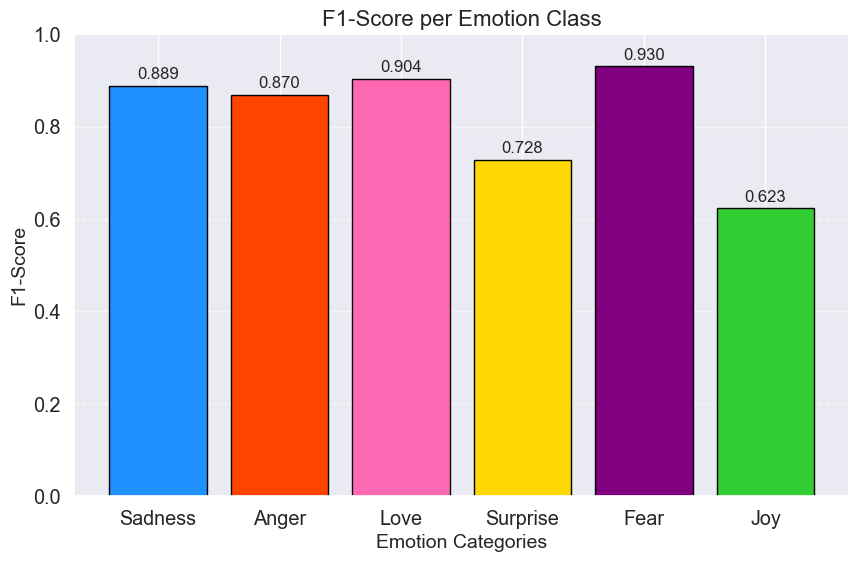

In [49]:
import matplotlib.pyplot as plt

# Actual emotions and F1-scores
emotions = ['Sadness', 'Anger', 'Love', 'Surprise', 'Fear', 'Joy']
f1_scores = [0.888889, 0.869565, 0.903631, 0.728477, 0.930396, 0.622951]
colors = ['#1E90FF', '#FF4500', '#FF69B4', '#FFD700', '#800080', '#32CD32']

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(emotions, f1_scores, color=colors, edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
             f"{bar.get_height():.3f}", ha='center', fontsize=12)

# Titles and labels
plt.title('F1-Score per Emotion Class', fontsize=16)
plt.xlabel('Emotion Categories', fontsize=14)
plt.ylabel('F1-Score', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()
